# Trained PPO Agent - Beamforming Performance Test

학습 완료된 PPO 에이전트의 빔포밍 성능을 평가합니다.
- 평균 SIR (Signal-to-Interference Ratio)
- Desired 방향 이득 (PD_dB)
- Interference 방향 억압 (PI_dB)
- Array Factor Pattern 시각화

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from radar_env import RADARDynamic
from ppo_agent import PPOAgent
import os
import glob

sns.set_style("whitegrid")
%matplotlib inline

## 1. 모델 로드

가장 최근 학습된 모델을 자동으로 찾아 로드합니다.

In [17]:
# 가장 최신 학습 결과 디렉토리 자동 탐색
result_dirs = sorted(glob.glob('results/ppo_training_*'))
print("Available models:")
for i, d in enumerate(result_dirs):
    print(f"  [{i}] {d}")

# 최신 모델 선택 (마지막 항목)
MODEL_DIR = result_dirs[-2]
MODEL_PATH = os.path.join(MODEL_DIR, 'trained_agent.pth')
print(f"\nSelected model: {MODEL_PATH}")

Available models:
  [0] results\ppo_training_20260219_114901
  [1] results\ppo_training_20260219_144826
  [2] results\ppo_training_20260219_213937
  [3] results\ppo_training_20260220_111720
  [4] results\ppo_training_20260222_214417
  [5] results\ppo_training_20260223_145419
  [6] results\ppo_training_20260223_193115
  [7] results\ppo_training_20260224_142058
  [8] results\ppo_training_20260226_095509
  [9] results\ppo_training_20260316_110843
  [10] results\ppo_training_20260419_221249
  [11] results\ppo_training_20260427_103406

Selected model: results\ppo_training_20260419_221249\trained_agent.pth


In [19]:
# 학습 시 사용한 동일한 환경 설정으로 생성
env = RADARDynamic(
    num_elements=8,
    snr_db=5.0,
    isr_db=0.0,
    num_interferers=1,
    output_mode='triu_norm',
    max_steps=1024,
    desired_delta_deg=1.0,
    int_delta_deg=0.0,
    gain_mode='directivity',
)

state_size = env.observation_space.shape[0]
action_size = env.action_space.shape[0]
print(f"State size: {state_size}, Action size: {action_size}")

# PPO Agent 생성 및 모델 로드
agent = PPOAgent(
    state_size=state_size,
    action_size=action_size,
)
agent.load(MODEL_PATH)
agent.training = False
print("Model loaded successfully!")

State size: 72, Action size: 16
PPO Agent Initialized
Device: cpu
State size: 72
Action size: 16
Learning rate: 0.0003
Clip range: 0.2
Buffer size: 2048
Batch size: 128


RuntimeError: Error(s) in loading state_dict for ActorNetwork:
	size mismatch for shared.0.weight: copying a param with shape torch.Size([128, 73]) from checkpoint, the shape in current model is torch.Size([128, 72]).

## 2. 다중 에피소드 테스트

여러 에피소드에 걸쳐 에이전트 성능을 평가합니다.

In [ ]:
NUM_EPISODES = 5
ANGLE_THRESHOLD = 10.0  # 학습과 동일한 각도 임계값

all_episode_sirs = []
all_episode_pds = []
all_episode_pis = []
all_trajectories = []

for ep in range(NUM_EPISODES):
    # 학습과 동일: 간섭 0°로 고정
    state, info = env.reset(options={'int_angles_deg': [0.0]})
    done = False
    truncated = False

    step_sirs = []
    step_pds = []
    step_pis = []
    desired_angles = []
    int_angles = []

    step_count = 0
    valid_count = 0
    while not (done or truncated):
        action, _ = agent.select_action(state, deterministic=True)
        next_state, _, done, truncated, step_info = env.step(action)

        angle_diff = abs(step_info['desired_angle'] - step_info['int_angles_deg'][0])

        # 학습과 동일: 각도 차이 >= 10° 스텝만 메트릭 수집
        if angle_diff >= ANGLE_THRESHOLD:
            step_sirs.append(step_info['SIR_dB'])
            step_pds.append(step_info['PD_dB'])
            step_pis.append(step_info['PI_dB'])
            desired_angles.append(step_info['desired_angle'])
            int_angles.append(step_info['int_angles_deg'][0])
            valid_count += 1

        state = next_state
        step_count += 1

    if len(step_sirs) == 0:
        continue

    avg_sir = np.mean(step_sirs)
    avg_pd = np.mean(step_pds)
    avg_pi = np.mean(step_pis)

    all_episode_sirs.append(avg_sir)
    all_episode_pds.append(avg_pd)
    all_episode_pis.append(avg_pi)
    all_trajectories.append({
        'sirs': step_sirs,
        'pds': step_pds,
        'pis': step_pis,
        'desired_angles': desired_angles,
        'int_angles': int_angles,
    })

    print(f"Episode {ep+1:3d}/{NUM_EPISODES} | "
          f"Avg SIR: {avg_sir:7.2f} dB | "
          f"Avg PD: {avg_pd:7.2f} dB | "
          f"Avg PI: {avg_pi:7.2f} dB | "
          f"Steps: {step_count} (valid: {valid_count})")

Episode   1/5 | Avg SIR:   27.20 dB | Avg PD:    9.15 dB | Avg PI:  -18.05 dB | Steps: 1024 (valid: 791)
Episode   2/5 | Avg SIR:   26.73 dB | Avg PD:    9.20 dB | Avg PI:  -17.53 dB | Steps: 1024 (valid: 786)
Episode   3/5 | Avg SIR:   27.15 dB | Avg PD:    9.15 dB | Avg PI:  -18.00 dB | Steps: 1024 (valid: 793)
Episode   4/5 | Avg SIR:   26.89 dB | Avg PD:    9.19 dB | Avg PI:  -17.70 dB | Steps: 1024 (valid: 776)
Episode   5/5 | Avg SIR:   26.71 dB | Avg PD:    9.19 dB | Avg PI:  -17.52 dB | Steps: 1024 (valid: 777)


: 

: 

In [ ]:
# 전체 통계 요약
print("=" * 65)
print("                    Test Results Summary")
print("=" * 65)
print(f"  Episodes tested     : {NUM_EPISODES}")
print(f"  Mean SIR            : {np.mean(all_episode_sirs):.2f} +/- {np.std(all_episode_sirs):.2f} dB")
print(f"  Min  SIR            : {np.min(all_episode_sirs):.2f} dB")
print(f"  Max  SIR            : {np.max(all_episode_sirs):.2f} dB")
print(f"  Median SIR          : {np.median(all_episode_sirs):.2f} dB")
print("-" * 65)
print(f"  Mean PD (desired)   : {np.mean(all_episode_pds):.2f} +/- {np.std(all_episode_pds):.2f} dB")
print(f"  Mean PI (interf.)   : {np.mean(all_episode_pis):.2f} +/- {np.std(all_episode_pis):.2f} dB")
print("=" * 65)

                    Test Results Summary
  Episodes tested     : 5
  Mean SIR            : 26.94 +/- 0.21 dB
  Min  SIR            : 26.71 dB
  Max  SIR            : 27.20 dB
  Median SIR          : 26.89 dB
-----------------------------------------------------------------
  Mean PD (desired)   : 9.18 +/- 0.02 dB
  Mean PI (interf.)   : -17.76 +/- 0.23 dB


: 

: 

## 3. Episode별 SIR / PD / PI 분포

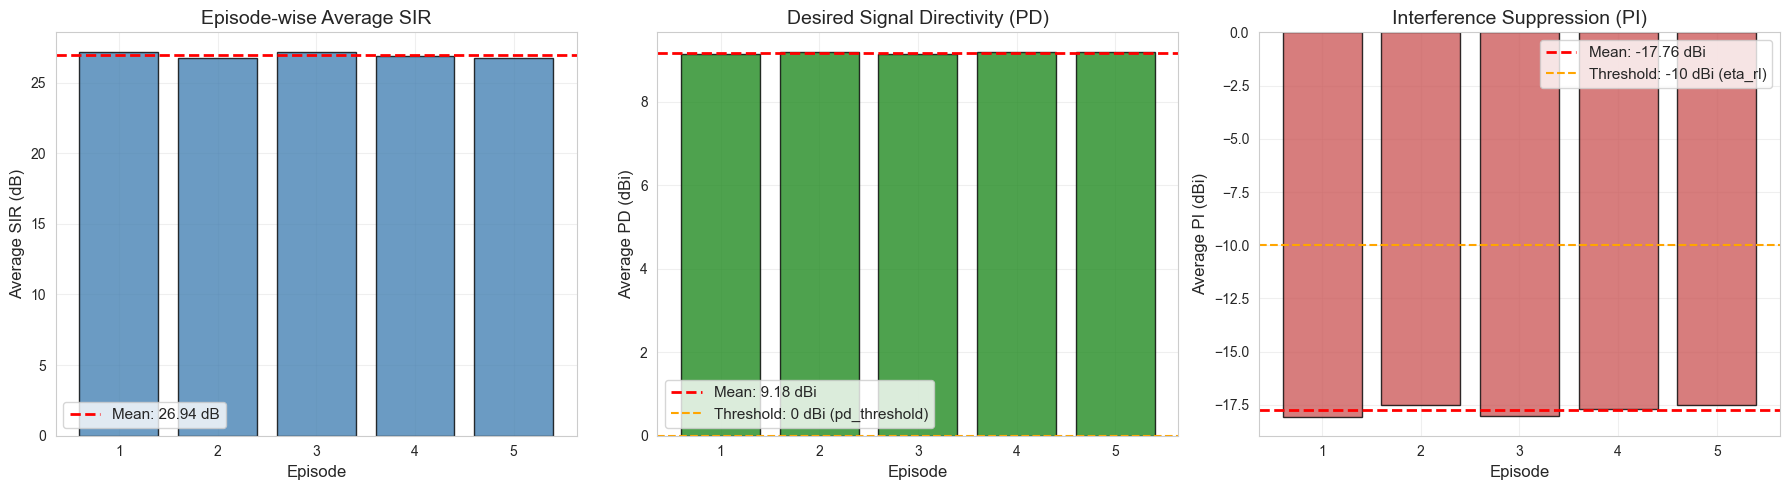

: 

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SIR 분포
ax = axes[0]
ax.bar(range(1, NUM_EPISODES+1), all_episode_sirs, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(all_episode_sirs), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(all_episode_sirs):.2f} dB')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Average SIR (dB)', fontsize=12)
ax.set_title('Episode-wise Average SIR', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# PD 분포
ax = axes[1]
ax.bar(range(1, NUM_EPISODES+1), all_episode_pds, color='forestgreen', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(all_episode_pds), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(all_episode_pds):.2f} dBi')
ax.axhline(0.0, color='orange', linestyle='--', linewidth=1.5, label='Threshold: 0 dBi (pd_threshold)')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Average PD (dBi)', fontsize=12)
ax.set_title('Desired Signal Directivity (PD)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# PI 분포
ax = axes[2]
ax.bar(range(1, NUM_EPISODES+1), all_episode_pis, color='indianred', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(all_episode_pis), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(all_episode_pis):.2f} dBi')
ax.axhline(-10.0, color='orange', linestyle='--', linewidth=1.5, label='Threshold: -10 dBi (eta_rl)')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Average PI (dBi)', fontsize=12)
ax.set_title('Interference Suppression (PI)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 단일 에피소드 상세 분석

첫 번째 에피소드의 시간별 추이를 상세하게 분석합니다.

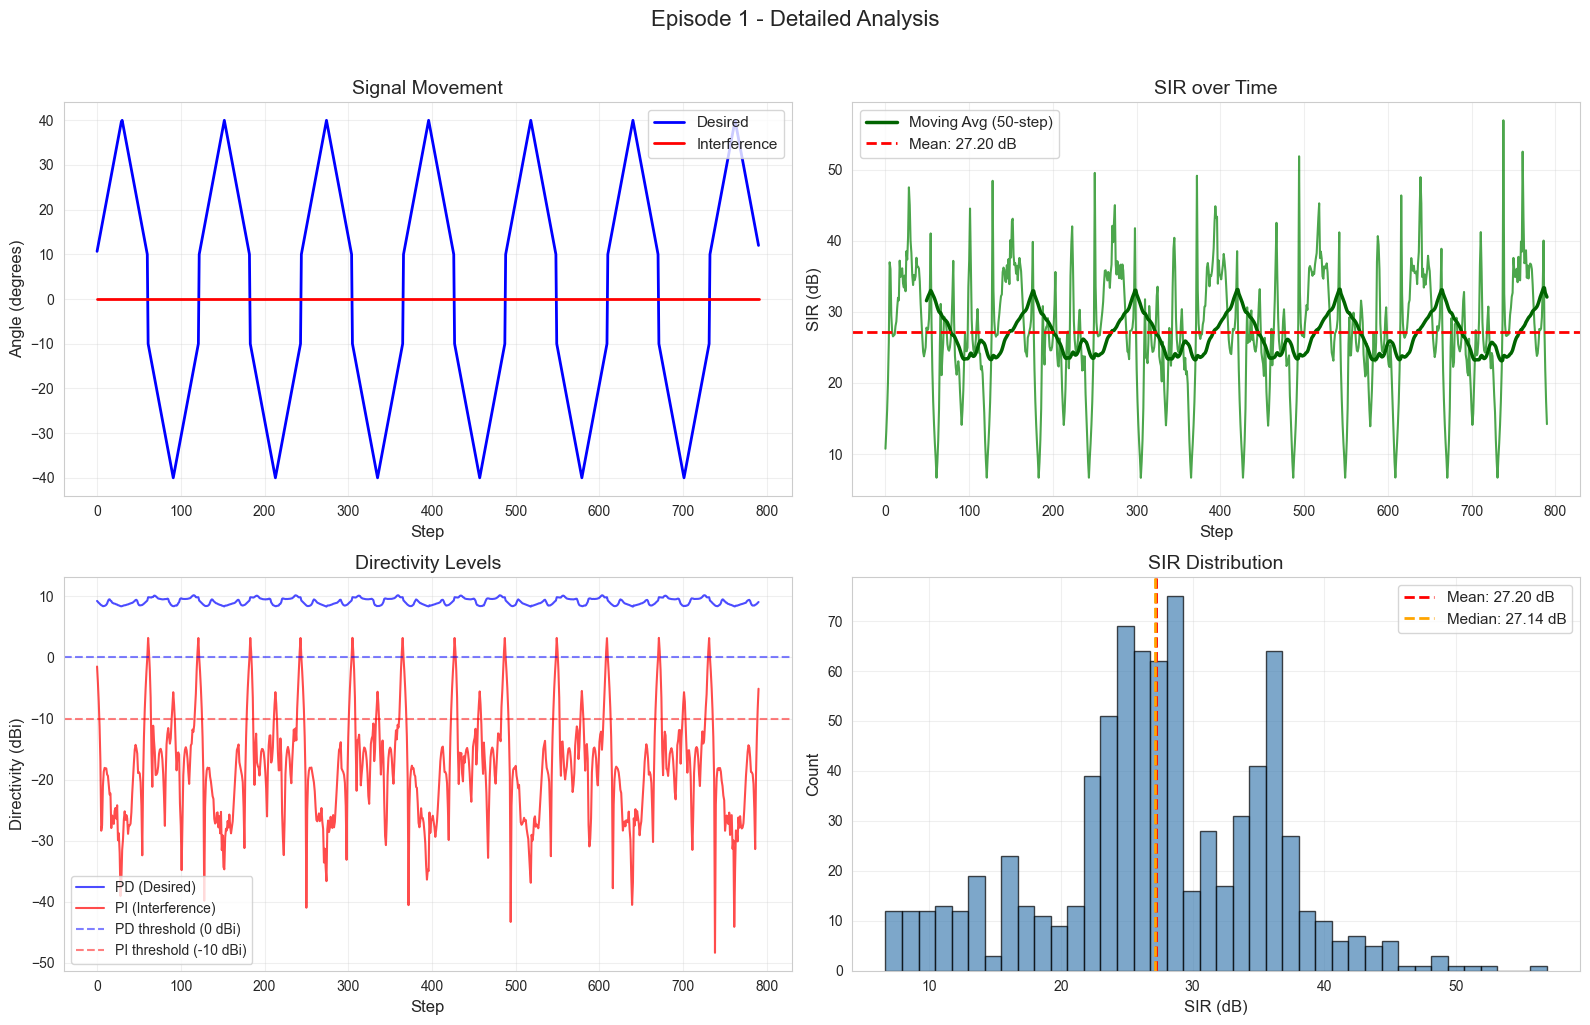

: 

: 

In [ ]:
# 첫 번째 에피소드 trajectory
traj = all_trajectories[0]
steps = range(len(traj['sirs']))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Desired / Interference 각도 변화
ax = axes[0, 0]
ax.plot(steps, traj['desired_angles'], 'b-', linewidth=2, label='Desired')
ax.plot(steps, traj['int_angles'], 'r-', linewidth=2, label='Interference')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Angle (degrees)', fontsize=12)
ax.set_title('Signal Movement', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# (2) SIR 시간 추이
ax = axes[0, 1]
ax.plot(steps, traj['sirs'], 'g-', linewidth=1.5, alpha=0.7)
window = 50
if len(traj['sirs']) > window:
    sir_ma = np.convolve(traj['sirs'], np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(traj['sirs'])), sir_ma, 'darkgreen', linewidth=2.5,
            label=f'Moving Avg ({window}-step)')
ax.axhline(np.mean(traj['sirs']), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(traj["sirs"]):.2f} dB')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('SIR (dB)', fontsize=12)
ax.set_title('SIR over Time', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# (3) PD / PI 시간 추이
ax = axes[1, 0]
ax.plot(steps, traj['pds'], 'b-', linewidth=1.5, alpha=0.7, label='PD (Desired)')
ax.plot(steps, traj['pis'], 'r-', linewidth=1.5, alpha=0.7, label='PI (Interference)')
ax.axhline(0.0, color='blue', linestyle='--', alpha=0.5, label='PD threshold (0 dBi)')
ax.axhline(-10.0, color='red', linestyle='--', alpha=0.5, label='PI threshold (-10 dBi)')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Directivity (dBi)', fontsize=12)
ax.set_title('Directivity Levels', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# (4) SIR 히스토그램
ax = axes[1, 1]
ax.hist(traj['sirs'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.mean(traj['sirs']), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(traj["sirs"]):.2f} dB')
ax.axvline(np.median(traj['sirs']), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {np.median(traj["sirs"]):.2f} dB')
ax.set_xlabel('SIR (dB)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('SIR Distribution', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('Episode 1 - Detailed Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5. Array Factor Pattern 시각화

특정 시점의 빔 패턴을 확인합니다. Desired 방향에 메인빔이 형성되고, Interference 방향에 null이 형성되는지 확인합니다.

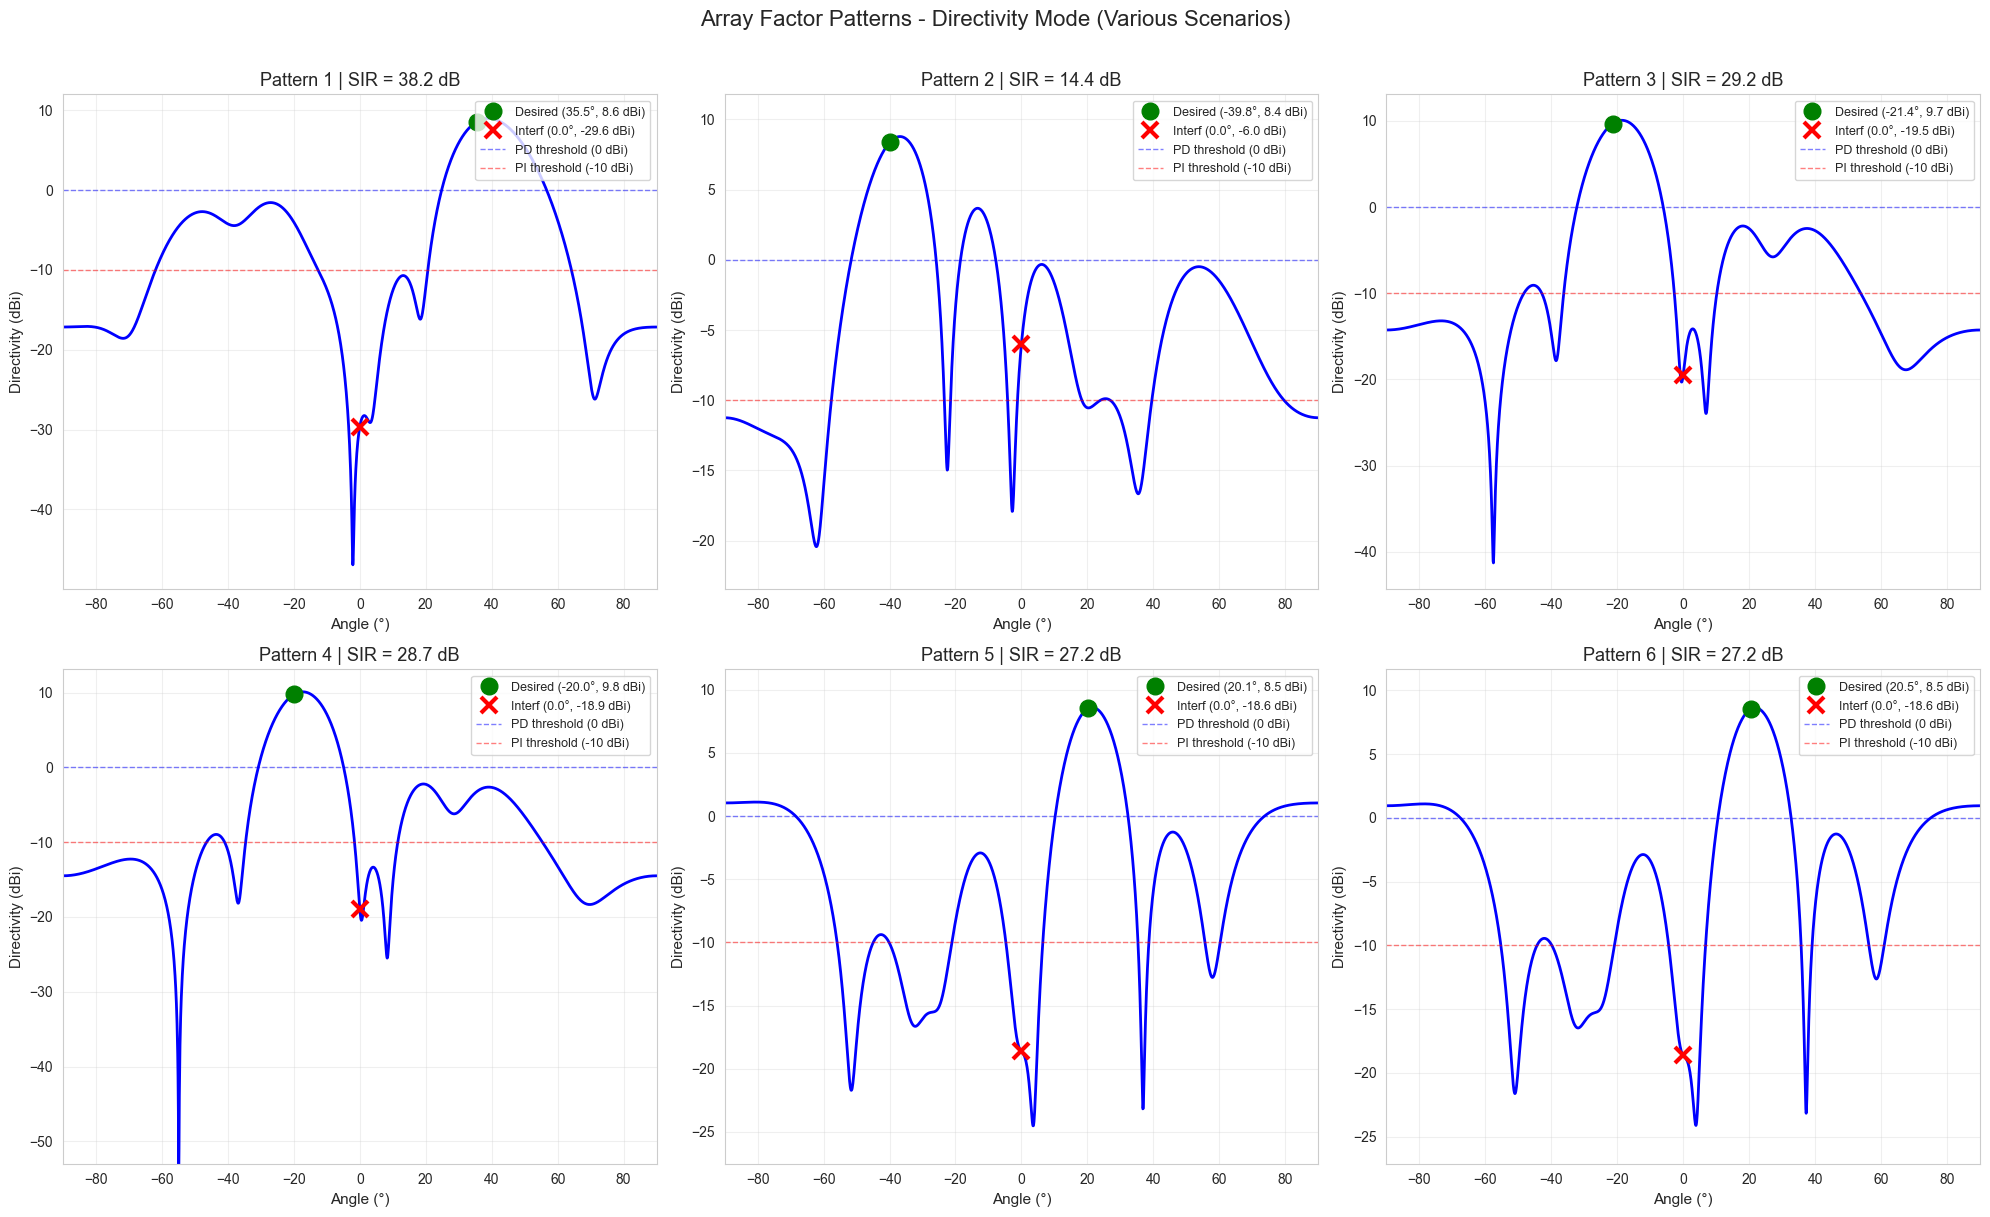

: 

: 

In [ ]:
# 여러 랜덤 초기 조건에서 Array Pattern 확인
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i in range(6):
    state, info = env.reset(options={'int_angles_deg': [0.0]})

    for _ in range(10):
        action, _ = agent.select_action(state, deterministic=True)
        state, _, done, truncated, step_info = env.step(action)
        if done or truncated:
            break

    action, _ = agent.select_action(state, deterministic=True)
    eval_info = env.evaluate(action)

    ax = axes[i]
    angles = eval_info['angles']
    AF_dB = eval_info['AF_pattern_dB']

    ax.plot(angles, AF_dB, 'b-', linewidth=2)

    theta_d = eval_info['theta_deg']
    pd = eval_info['PD_dB']
    ax.plot(theta_d, pd, 'go', markersize=12, zorder=5,
            label=f'Desired ({theta_d:.1f}°, {pd:.1f} dBi)')

    for q, (int_ang, pi_db) in enumerate(zip(eval_info['int_angles_deg'], eval_info['PI_dB_single'])):
        ax.plot(int_ang, pi_db, 'rx', markersize=12, markeredgewidth=3, zorder=5,
                label=f'Interf ({int_ang:.1f}°, {pi_db:.1f} dBi)')

    ax.axhline(0.0, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='PD threshold (0 dBi)')
    ax.axhline(-10.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='PI threshold (-10 dBi)')
    ax.set_xlim([-90, 90])
    ax.set_ylim([max(np.min(AF_dB), -50) - 3, np.max(AF_dB) + 3])
    ax.set_xlabel('Angle (°)', fontsize=11)
    ax.set_ylabel('Directivity (dBi)', fontsize=11)
    ax.set_title(f'Pattern {i+1} | SIR = {eval_info["SIR_dB"]:.1f} dB', fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Array Factor Patterns - Directivity Mode (Various Scenarios)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Desired/Interference 각도 차이에 따른 SIR 성능

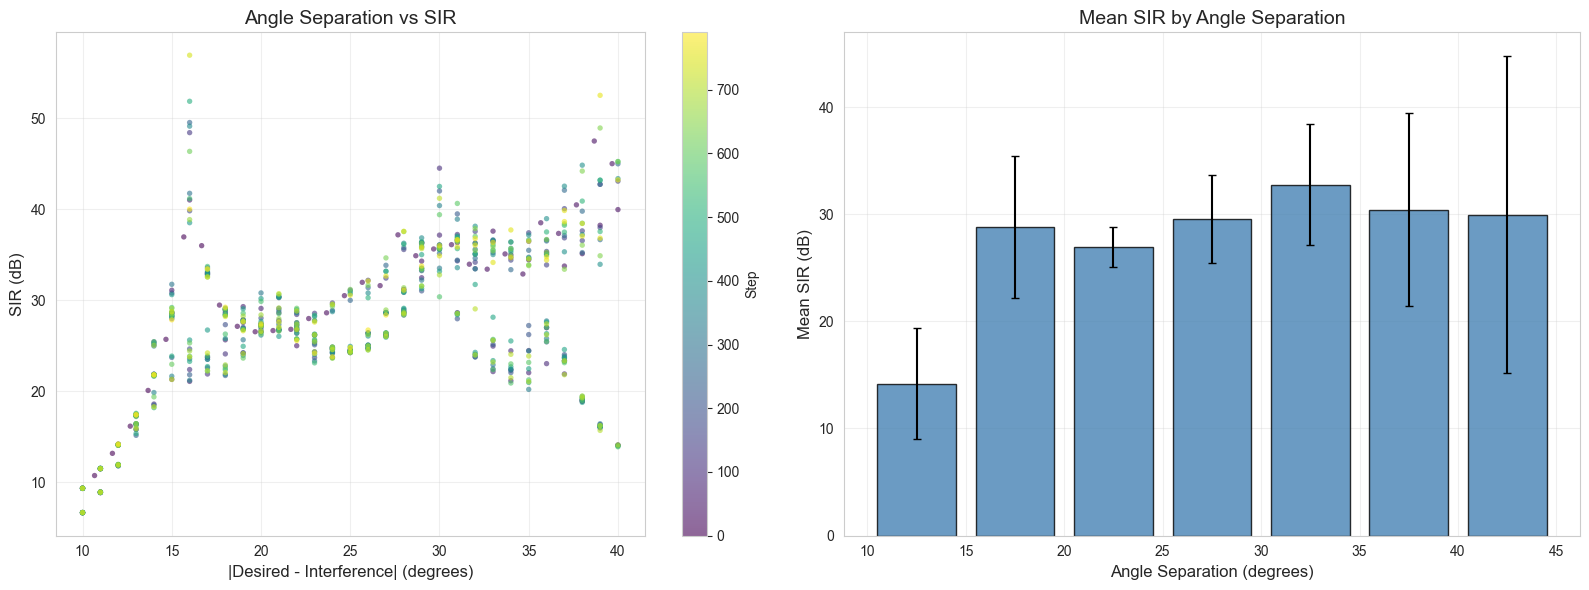

: 

: 

In [ ]:
# 첫 번째 에피소드의 각도 차이 vs SIR 관계
traj = all_trajectories[0]
angle_diffs = np.abs(np.array(traj['desired_angles']) - np.array(traj['int_angles']))
sirs = np.array(traj['sirs'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax = axes[0]
scatter = ax.scatter(angle_diffs, sirs, c=range(len(sirs)), cmap='viridis',
                     alpha=0.6, s=15, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Step')
ax.set_xlabel('|Desired - Interference| (degrees)', fontsize=12)
ax.set_ylabel('SIR (dB)', fontsize=12)
ax.set_title('Angle Separation vs SIR', fontsize=14)
ax.grid(True, alpha=0.3)

# 각도 구간별 평균 SIR
ax = axes[1]
bins = np.arange(0, 85, 5)
bin_indices = np.digitize(angle_diffs, bins)
bin_means = []
bin_stds = []
bin_centers = []
for b in range(1, len(bins)):
    mask = bin_indices == b
    if np.sum(mask) > 0:
        bin_means.append(np.mean(sirs[mask]))
        bin_stds.append(np.std(sirs[mask]))
        bin_centers.append((bins[b-1] + bins[b]) / 2)

ax.bar(bin_centers, bin_means, width=4, color='steelblue', edgecolor='black',
       alpha=0.8, yerr=bin_stds, capsize=3)
ax.set_xlabel('Angle Separation (degrees)', fontsize=12)
ax.set_ylabel('Mean SIR (dB)', fontsize=12)
ax.set_title('Mean SIR by Angle Separation', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 고정 시나리오 테스트

Desired 방향과 Interference 방향을 지정하여 특정 시나리오에서의 성능을 확인합니다.

Scenario                         SIR (dB)   PD (dBi)   PI (dBi)
-----------------------------------------------------------------
D=0°, I=30°                          3.05       9.91       6.87
D=20°, I=-20°                       34.34       9.07     -25.27
D=-30°, I=10°                       28.17       9.30     -18.87
D=10°, I=25° (close)                28.60       8.69     -19.92


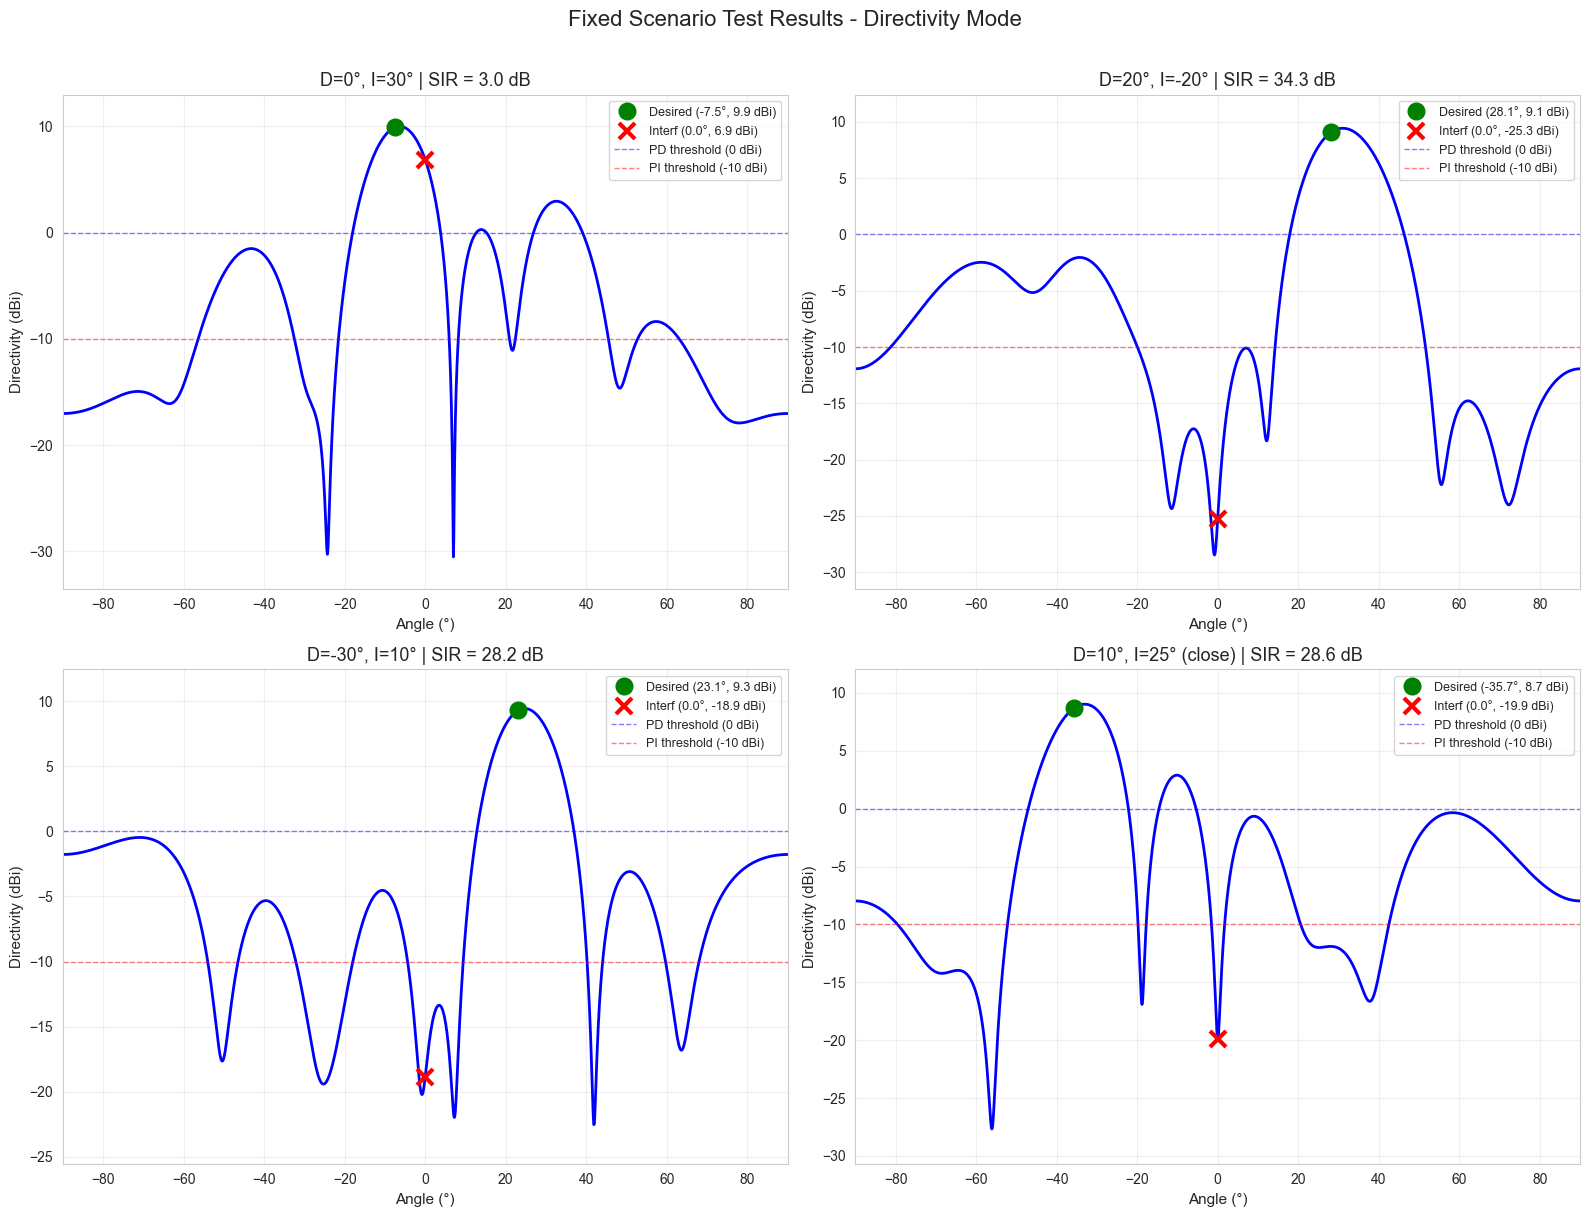

: 

: 

In [ ]:
# 테스트할 시나리오 정의
test_scenarios = [
    {'desired_angle': 0.0,   'int_angles_deg': [30.0],  'label': 'D=0°, I=30°'},
    {'desired_angle': 20.0,  'int_angles_deg': [-20.0], 'label': 'D=20°, I=-20°'},
    {'desired_angle': -30.0, 'int_angles_deg': [10.0],  'label': 'D=-30°, I=10°'},
    {'desired_angle': 10.0,  'int_angles_deg': [25.0],  'label': 'D=10°, I=25° (close)'},
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print(f"{'Scenario':<30s} {'SIR (dB)':>10s} {'PD (dBi)':>10s} {'PI (dBi)':>10s}")
print("-" * 65)

for i, scenario in enumerate(test_scenarios):
    state, info = env.reset(options={'int_angles_deg': [0.0]})

    for _ in range(5):
        action, _ = agent.select_action(state, deterministic=True)
        state, _, done, truncated, step_info = env.step(action)

    action, _ = agent.select_action(state, deterministic=True)
    eval_info = env.evaluate(action)

    print(f"{scenario['label']:<30s} {eval_info['SIR_dB']:10.2f} {eval_info['PD_dB']:10.2f} {eval_info['PI_dB']:10.2f}")

    ax = axes[i]
    AF_dB = eval_info['AF_pattern_dB']
    ax.plot(eval_info['angles'], AF_dB, 'b-', linewidth=2)
    ax.plot(eval_info['theta_deg'], eval_info['PD_dB'], 'go', markersize=12, zorder=5,
            label=f'Desired ({eval_info["theta_deg"]:.1f}°, {eval_info["PD_dB"]:.1f} dBi)')
    for q, (int_ang, pi_db) in enumerate(zip(eval_info['int_angles_deg'], eval_info['PI_dB_single'])):
        ax.plot(int_ang, pi_db, 'rx', markersize=12, markeredgewidth=3, zorder=5,
                label=f'Interf ({int_ang:.1f}°, {pi_db:.1f} dBi)')
    ax.axhline(0.0, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='PD threshold (0 dBi)')
    ax.axhline(-10.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='PI threshold (-10 dBi)')
    ax.set_xlim([-90, 90])
    ax.set_ylim([max(np.min(AF_dB), -50) - 3, np.max(AF_dB) + 3])
    ax.set_xlabel('Angle (°)', fontsize=11)
    ax.set_ylabel('Directivity (dBi)', fontsize=11)
    ax.set_title(f"{scenario['label']} | SIR = {eval_info['SIR_dB']:.1f} dB", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fixed Scenario Test Results - Directivity Mode', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 8. MVDR (Capon) Beamformer 비교

학습된 DRL 에이전트와 전통적인 MVDR 빔포머의 성능을 비교합니다.

In [ ]:
def mvdr_weights(Gamma, steering_vector):
    """MVDR (Capon) beamformer weights"""
    # 정규화를 위한 작은 대각 행렬 추가
    M = Gamma.shape[0]
    Gamma_reg = Gamma + 1e-6 * np.eye(M)
    Gamma_inv = np.linalg.inv(Gamma_reg)
    
    a = steering_vector
    w = Gamma_inv @ a
    w = w / (a.conj() @ Gamma_inv @ a)
    return w


NUM_COMPARE = 50
drl_sirs = []
mvdr_sirs = []
drl_pds = []
mvdr_pds = []

for ep in range(NUM_COMPARE):
    state, info = env.reset()
    
    # 몇 스텝 진행
    for _ in range(10):
        action, _ = agent.select_action(state, deterministic=True)
        state, _, done, truncated, step_info = env.step(action)
        if done or truncated:
            break
    
    # DRL agent
    action_drl, _ = agent.select_action(state, deterministic=True)
    eval_drl = env.evaluate(action_drl)
    drl_sirs.append(eval_drl['SIR_dB'])
    drl_pds.append(eval_drl['PD_dB'])
    
    # MVDR
    Gamma = env.current_gamma
    a_d = env._steer_vector(env.desired_angle)
    w_mvdr = mvdr_weights(Gamma, a_d)
    
    # MVDR를 action 형식으로 변환
    action_mvdr = np.concatenate([w_mvdr.real, w_mvdr.imag])
    eval_mvdr = env.evaluate(action_mvdr)
    mvdr_sirs.append(eval_mvdr['SIR_dB'])
    mvdr_pds.append(eval_mvdr['PD_dB'])

print(f"{'Method':<15s} {'Mean SIR (dB)':>15s} {'Std SIR (dB)':>15s} {'Mean PD (dB)':>15s}")
print("-" * 65)
print(f"{'DRL (PPO)':<15s} {np.mean(drl_sirs):15.2f} {np.std(drl_sirs):15.2f} {np.mean(drl_pds):15.2f}")
print(f"{'MVDR (Capon)':<15s} {np.mean(mvdr_sirs):15.2f} {np.std(mvdr_sirs):15.2f} {np.mean(mvdr_pds):15.2f}")

Method            Mean SIR (dB)    Std SIR (dB)    Mean PD (dB)
-----------------------------------------------------------------
DRL (PPO)                 16.29           13.22            9.40
MVDR (Capon)               0.58            9.90           -3.43


: 

: 

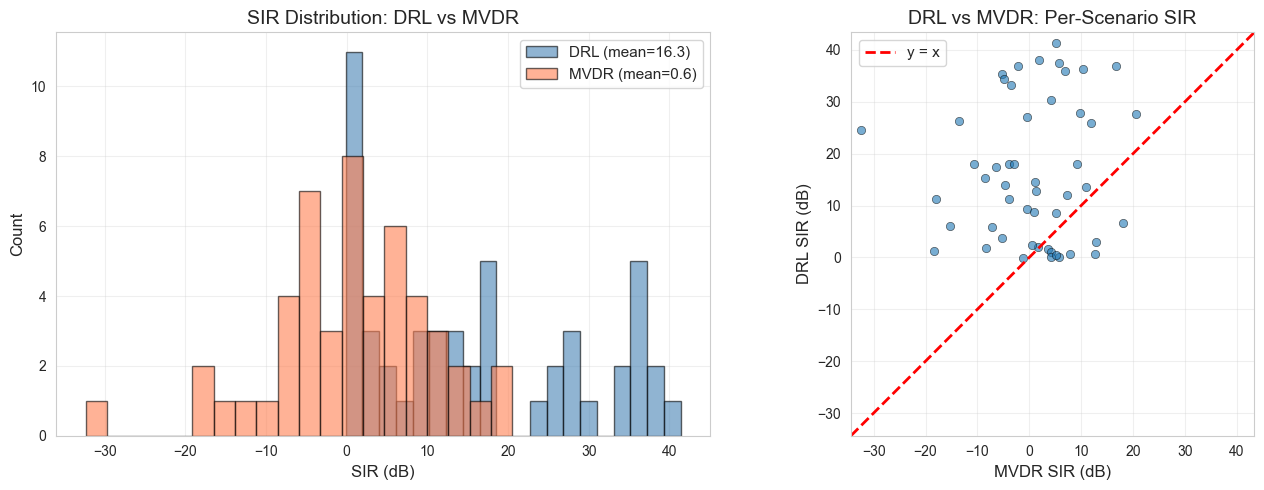


DRL wins: 82.0% of scenarios


: 

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SIR 비교 히스토그램
ax = axes[0]
ax.hist(drl_sirs, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label=f'DRL (mean={np.mean(drl_sirs):.1f})')
ax.hist(mvdr_sirs, bins=20, alpha=0.6, color='coral', edgecolor='black', label=f'MVDR (mean={np.mean(mvdr_sirs):.1f})')
ax.set_xlabel('SIR (dB)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('SIR Distribution: DRL vs MVDR', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Paired comparison (scatter)
ax = axes[1]
ax.scatter(mvdr_sirs, drl_sirs, alpha=0.6, edgecolors='black', linewidths=0.5)
lim_min = min(min(drl_sirs), min(mvdr_sirs)) - 2
lim_max = max(max(drl_sirs), max(mvdr_sirs)) + 2
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='y = x')
ax.set_xlabel('MVDR SIR (dB)', fontsize=12)
ax.set_ylabel('DRL SIR (dB)', fontsize=12)
ax.set_title('DRL vs MVDR: Per-Scenario SIR', fontsize=14)
ax.set_xlim([lim_min, lim_max])
ax.set_ylim([lim_min, lim_max])
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

win_rate = np.mean(np.array(drl_sirs) > np.array(mvdr_sirs)) * 100
print(f"\nDRL wins: {win_rate:.1f}% of scenarios")

## 9. Polar Plot (Beam Pattern)

빔 패턴을 극좌표로 시각화합니다.

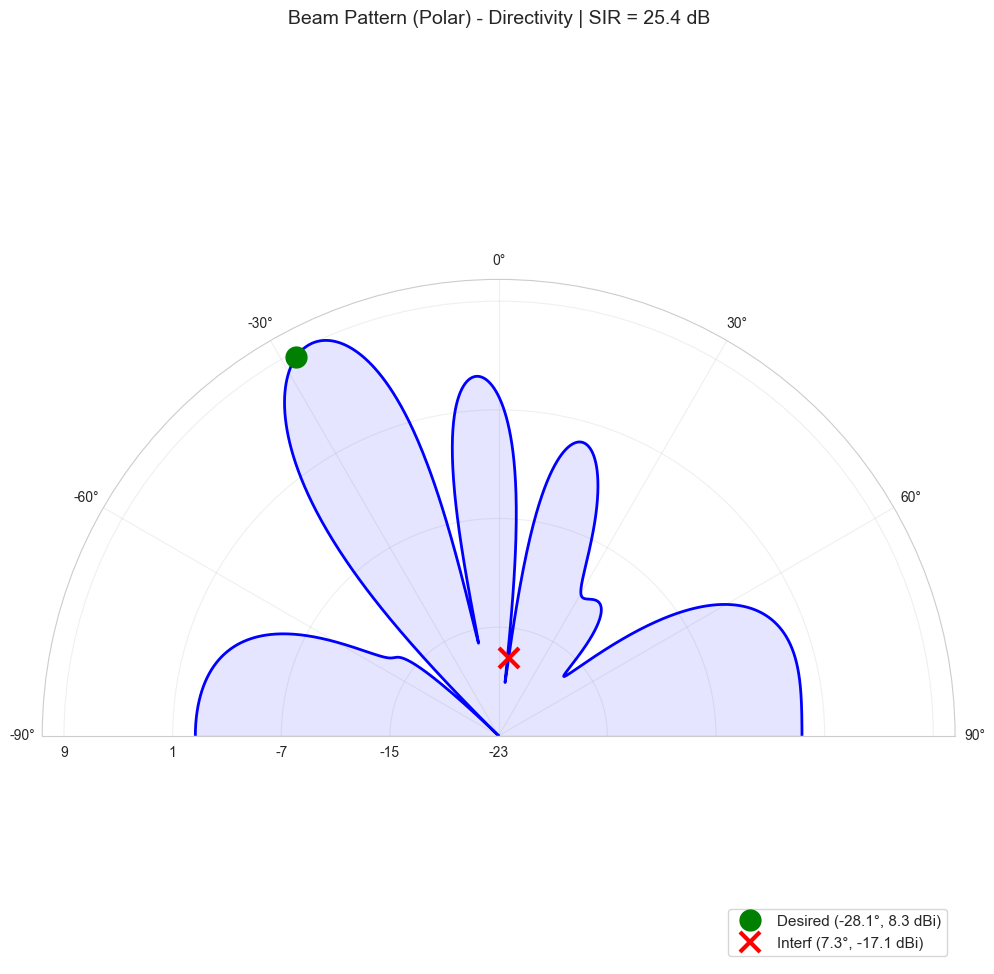

: 

: 

In [ ]:
state, info = env.reset()
for _ in range(10):
    action, _ = agent.select_action(state, deterministic=True)
    state, _, done, truncated, _ = env.step(action)

action, _ = agent.select_action(state, deterministic=True)
eval_info = env.evaluate(action)

angles_rad = np.deg2rad(eval_info['angles'])
AF_dB = eval_info['AF_pattern_dB']

# Directivity mode: peak ~9 dBi, dynamic range [-50, peak]
af_min = max(np.min(AF_dB), -50)
af_max = np.max(AF_dB)
shift = -af_min  # shift so minimum maps to 0
AF_plot = np.clip(AF_dB, af_min, af_max) + shift

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
ax.plot(angles_rad, AF_plot, 'b-', linewidth=2)
ax.fill(angles_rad, AF_plot, alpha=0.1, color='blue')

# Desired direction
theta_d_rad = np.deg2rad(eval_info['theta_deg'])
pd_plot = np.clip(eval_info['PD_dB'], af_min, af_max) + shift
ax.plot(theta_d_rad, pd_plot, 'go', markersize=15,
        label=f'Desired ({eval_info["theta_deg"]:.1f}°, {eval_info["PD_dB"]:.1f} dBi)')

# Interference direction
for q, int_ang in enumerate(eval_info['int_angles_deg']):
    int_rad = np.deg2rad(int_ang)
    pi_plot = np.clip(eval_info['PI_dB_single'][q], af_min, af_max) + shift
    ax.plot(int_rad, pi_plot, 'rx', markersize=15, markeredgewidth=3,
            label=f'Interf ({int_ang:.1f}°, {eval_info["PI_dB_single"][q]:.1f} dBi)')

# Radial tick labels (show actual dBi values)
n_ticks = 5
tick_vals = np.linspace(af_min, af_max, n_ticks)
ax.set_rticks(tick_vals + shift)
ax.set_yticklabels([f'{v:.0f}' for v in tick_vals])

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_title(f'Beam Pattern (Polar) - Directivity | SIR = {eval_info["SIR_dB"]:.1f} dB', fontsize=14, pad=20)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()